### Import libraries

In [1]:
# importing required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency,kruskal
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC


In [2]:
# loading the dataset
fhp_df = pd.read_csv('financial_health.csv')

In [3]:

fhp_df.head()

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
0,ID_3CFL0U,eswatini,63.0,Yes,No,No,No,Yes,3000.0,6000.0,...,Never had,Never had,NaN,6.0,Never had,Used to have but don’t have now,NaN,Never had,Never had,Low
1,ID_XWI7G3,zimbabwe,39.0,No,Yes,Yes,No,Yes,NaN,NaN,...,NaN,NaN,No,3.0,Never had,Never had,NaN,NaN,NaN,Medium
2,ID_TY93LV,malawi,34.0,Don’t know or N/A,No,No,Don't know,Yes,30000.0,6000.0,...,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
3,ID_9OP2C8,malawi,28.0,Yes,No,No,No,No,180000.0,60000.0,...,Never had,Never had,No,NaN,NaN,NaN,Yes,Never had,Have now,Low
4,ID_13REYS,zimbabwe,43.0,Yes,No,No,Yes,Yes,50.0,2400.0,...,NaN,NaN,No,0.0,Never had,Never had,Yes,NaN,NaN,Low


Performing the basicc checks of the data

In [4]:
def basic_checks(data_df):
    print('Structure of the Data\n', data_df.shape)   
    print('='*100)
    print('Duplicates\n', data_df.duplicated().sum())
    print('='*100)
    print('Columns\n', data_df.columns)
    print('='*100)
    missing_count = data_df.isna().sum() 
    missing_count_pct = (data_df.isna().sum()/len(data_df))*100
    missing_values = pd.concat([missing_count, missing_count_pct], axis = 1)
    print('Missing Value\n', missing_values)
    print('='*100)
    print('Data-Types\n', data_df.info(verbose=True))
    print('='*100)  
    print('Numerical Column Summary\n', display(data_df.describe().T))
    print('='*100)
    print('Categorical Summary\n', display(data_df.describe(include=['object']).T))
  
    


In [5]:
basic_checks(fhp_df)

Structure of the Data
 (9618, 39)
Duplicates
 0
Columns
 Index(['ID', 'country', 'owner_age', 'attitude_stable_business_environment',
       'attitude_worried_shutdown', 'compliance_income_tax',
       'perception_insurance_doesnt_cover_losses',
       'perception_cannot_afford_insurance', 'personal_income',
       'business_expenses', 'business_turnover', 'business_age_years',
       'motor_vehicle_insurance', 'has_mobile_money',
       'current_problem_cash_flow', 'has_cellphone', 'owner_sex',
       'offers_credit_to_customers', 'attitude_satisfied_with_achievement',
       'has_credit_card', 'keeps_financial_records',
       'perception_insurance_companies_dont_insure_businesses_like_yours',
       'perception_insurance_important', 'has_insurance',
       'covid_essential_service', 'attitude_more_successful_next_year',
       'problem_sourcing_money', 'marketing_word_of_mouth', 'has_loan_account',
       'has_internet_banking', 'has_debit_card', 'future_risk_theft_stock',
       'b

,count,mean,std,min,25%,50%,75%,max
owner_age,9618.0,4.170534e+01,1.331401e+01,18.0,32.0,40.0,50.0,103.0
personal_income,9509.0,2.627345e+05,2.566268e+06,0.0,300.0,2000.0,25000.0,150000000.0
business_expenses,9389.0,4.583838e+05,6.184746e+06,0.0,700.0,3000.0,25000.0,500000000.0
business_turnover,9402.0,1.348210e+06,8.804741e+06,0.0,1500.0,6000.0,50000.0,420000000.0
business_age_years,9366.0,7.030536e+00,7.650349e+00,0.0,2.0,4.0,10.0,60.0
business_age_months,5507.0,3.636281e+00,3.386488e+00,0.0,0.0,3.0,6.0,11.0


Numerical Column Summary
 None


C:\Users\JULES\AppData\Local\Temp\ipykernel_12300\3177196593.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print('Categorical Summary\n', display(data_df.describe(include=['object']).T))


,count,unique,top,freq
ID,9618,9618,ID_3CFL0U,1
country,9618,4,eswatini,2674
attitude_stable_business_environment,9616,3,Yes,5820
attitude_worried_shutdown,9616,3,No,5804
compliance_income_tax,9614,4,No,8010
perception_insurance_doesnt_cover_losses,9613,3,No,4486
perception_cannot_afford_insurance,9613,3,Yes,6056
motor_vehicle_insurance,7374,4,Never had,6994
has_mobile_money,6867,5,Have now,4876
current_problem_cash_flow,5840,3,Yes,2688


Categorical Summary
 None


## Data Cleaning

In [6]:
cat_columns = fhp_df.select_dtypes(include=['str','object']).columns.to_list()
cat_columns

['ID',
 'country',
 'attitude_stable_business_environment',
 'attitude_worried_shutdown',
 'compliance_income_tax',
 'perception_insurance_doesnt_cover_losses',
 'perception_cannot_afford_insurance',
 'motor_vehicle_insurance',
 'has_mobile_money',
 'current_problem_cash_flow',
 'has_cellphone',
 'owner_sex',
 'offers_credit_to_customers',
 'attitude_satisfied_with_achievement',
 'has_credit_card',
 'keeps_financial_records',
 'perception_insurance_companies_dont_insure_businesses_like_yours',
 'perception_insurance_important',
 'has_insurance',
 'covid_essential_service',
 'attitude_more_successful_next_year',
 'problem_sourcing_money',
 'marketing_word_of_mouth',
 'has_loan_account',
 'has_internet_banking',
 'has_debit_card',
 'future_risk_theft_stock',
 'medical_insurance',
 'funeral_insurance',
 'motivation_make_more_money',
 'uses_friends_family_savings',
 'uses_informal_lender',
 'Target']

In [7]:
#applying trimming and Tittle to the categorical columns
for cols in cat_columns:
    fhp_df[cols]=fhp_df[cols].str.strip().str.lower()

In [8]:
for col in cat_columns:
    print(60 * '=', col, 60*'=')
    print(fhp_df[col].unique())

============================================================ ID ============================================================
<StringArray>
['id_3cfl0u', 'id_xwi7g3', 'id_ty93lv', 'id_9op2c8', 'id_13reys', 'id_57i1ni',
 'id_l3tkqv', 'id_kb700u', 'id_duqi8u', 'id_27yh6u',
 ...
 'id_3bqmn8', 'id_kum88b', 'id_hyhp38', 'id_p3id6d', 'id_yfhjfc', 'id_d7nc2d',
 'id_nt06rl', 'id_4tvwa3', 'id_3u3s2z', 'id_4xgohm']
Length: 9618, dtype: str
============================================================ country ============================================================
<StringArray>
['eswatini', 'zimbabwe', 'malawi', 'lesotho']
Length: 4, dtype: str
============================================================ attitude_stable_business_environment ============================================================
<StringArray>
['yes', 'no', 'don’t know or n/a', nan]
Length: 4, dtype: str
============================================================ attitude_worried_shutdown =================================

In [9]:
#standardising  has_mobile_money column
fhp_df['has_mobile_money']=fhp_df['has_mobile_money'].replace({
    'used to have but don\'t have now':'used to have but don’t have now'
})

In [10]:
#standardising current_problem_cash_flow column
fhp_df['current_problem_cash_flow']=fhp_df['current_problem_cash_flow'].replace({
    '0':'no'
})

In [11]:
#standardising  attitude_satisfied_with_achievement columns
fhp_df['attitude_satisfied_with_achievement']=fhp_df['attitude_satisfied_with_achievement'].replace({
    'don’t know or n/a':'don\'t know'
})

In [12]:
#standardising  has_credit_card  columns
fhp_df['has_credit_card']=fhp_df['has_credit_card'].replace({
    'used to have but don\'t have now':'used to have but don’t have now'
})


In [13]:
#standardising  keeps_financial_records columns
fhp_df['keeps_financial_records']=fhp_df['keeps_financial_records'].replace({
    'yes':'yes, always'
})

In [14]:
#standardising perception_insurance_companies_dont_insure_businesses_like_yours columns
fhp_df['perception_insurance_companies_dont_insure_businesses_like_yours']=fhp_df['perception_insurance_companies_dont_insure_businesses_like_yours'].replace({
    'don\'t know':'do not know / n\u200e/a'
})

In [15]:
#standardising perception_insurance_important columns
fhp_df['perception_insurance_important']=fhp_df['perception_insurance_important'].replace({
    'don?t know / doesn?t apply':'don\'t know'
})

In [16]:
#standardising perception_insurance_important columns
fhp_df['perception_insurance_important']=fhp_df['perception_insurance_important'].replace({
    'don\'t know':'do not know / n\u200e/a'
})

In [17]:
#standardising attitude_more_successful_next_year columns
fhp_df['attitude_more_successful_next_year']=fhp_df['attitude_more_successful_next_year'].replace({
    'don\'t know':'don’t know or n/a'
})


In [18]:
#standardising has_loan_account columns
fhp_df['has_loan_account']=fhp_df['has_loan_account'].replace({
    'used to have but don\'t have now':'used to have but don’t have now',
    'don’t know (do not show)': 'don\'t know'})

In [19]:
#standardising has_internet_banking columns
fhp_df['has_internet_banking']=fhp_df['has_internet_banking'].replace({
    'used to have but don\'t have now':'used to have but don’t have now',
    'don’t know (do not show)': 'don\'t know'})

In [20]:
 #standardising has_debit_card columns
fhp_df['has_internet_banking']=fhp_df['has_internet_banking'].replace({
    'used to have but don\'t have now':'used to have but don’t have now'})

In [21]:
 #standardising funeral_insurance columns
fhp_df['funeral_insurance']=fhp_df['funeral_insurance'].replace({
    'used to have but don\'t have now':'used to have but don’t have now'})

In [22]:
# standardising uses_friends_family_savings columns
fhp_df['uses_friends_family_savings']=fhp_df['uses_friends_family_savings'].replace({
    'used to have but don\'t have now':'used to have but don’t have now',
    'don’t know (do not show)': 'don\'t know'})


In [23]:
# standardising uses_informal_lender columns
fhp_df['uses_informal_lender']=fhp_df['uses_informal_lender'].replace({
    'used to have but don\'t have now':'used to have but don’t have now',
    'don’t know (do not show)': 'don\'t know'})


### Handling missing values for categorical columns

In [24]:
#Categorical columns
cat_df = fhp_df.select_dtypes(include=['category', 'object','str'])
cat_df

,ID,country,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,motor_vehicle_insurance,has_mobile_money,current_problem_cash_flow,...,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
0,id_3cfl0u,eswatini,yes,no,no,no,yes,never had,have now,yes,...,never had,never had,never had,NaN,never had,used to have but don’t have now,NaN,never had,never had,low
1,id_xwi7g3,zimbabwe,no,yes,yes,no,yes,have now,have now,NaN,...,NaN,NaN,NaN,no,never had,never had,NaN,NaN,NaN,medium
2,id_ty93lv,malawi,don’t know or n/a,no,no,don't know,yes,NaN,never had,yes,...,never had,never had,never had,yes,NaN,NaN,yes,NaN,NaN,low
3,id_9op2c8,malawi,yes,no,no,no,no,NaN,have now,no,...,never had,never had,never had,no,NaN,NaN,yes,never had,have now,low
4,id_13reys,zimbabwe,yes,no,no,yes,yes,never had,NaN,NaN,...,NaN,NaN,NaN,no,never had,never had,yes,NaN,NaN,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9613,id_d7nc2d,lesotho,yes,no,no,don't know,don't know,never had,have now,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,no,have now,never had,medium
9614,id_nt06rl,malawi,don’t know or n/a,don’t know or n/a,yes,no,no,NaN,have now,no,...,never had,never had,have now,yes,NaN,NaN,no,NaN,NaN,high
9615,id_4tvwa3,zimbabwe,yes,no,no,yes,no,never had,have now,NaN,...,NaN,NaN,NaN,no,have now,have now,NaN,NaN,NaN,medium
9616,id_3u3s2z,zimbabwe,yes,yes,no,no,yes,never had,NaN,NaN,...,NaN,NaN,NaN,no,never had,never had,NaN,NaN,NaN,low


In [25]:
missing_columns =round((cat_df.isna().sum()/len(cat_df))*100)
missing_columns[missing_columns>35]

current_problem_cash_flow      39.0
problem_sourcing_money         37.0
marketing_word_of_mouth        38.0
has_loan_account               42.0
has_internet_banking           42.0
has_debit_card                 42.0
future_risk_theft_stock        43.0
medical_insurance              44.0
funeral_insurance              44.0
motivation_make_more_money     45.0
uses_friends_family_savings    47.0
uses_informal_lender           47.0
dtype: float64

### Filling the columns with >35% isnull with a placeholder (unknown)

In [26]:
cols_missing_vals = missing_columns[missing_columns>35].index
cols_missing_vals

Index(['current_problem_cash_flow', 'problem_sourcing_money',
       'marketing_word_of_mouth', 'has_loan_account', 'has_internet_banking',
       'has_debit_card', 'future_risk_theft_stock', 'medical_insurance',
       'funeral_insurance', 'motivation_make_more_money',
       'uses_friends_family_savings', 'uses_informal_lender'],
      dtype='str')

In [27]:
fhp_df[cols_missing_vals]=fhp_df[cols_missing_vals].fillna('unknown')

In [28]:
(fhp_df.isnull().sum()/len(fhp_df))*100

ID                                                                   0.000000
country                                                              0.000000
owner_age                                                            0.000000
attitude_stable_business_environment                                 0.020794
attitude_worried_shutdown                                            0.020794
compliance_income_tax                                                0.041589
perception_insurance_doesnt_cover_losses                             0.051986
perception_cannot_afford_insurance                                   0.051986
personal_income                                                      1.133292
business_expenses                                                    2.380952
business_turnover                                                    2.245789
business_age_years                                                   2.620087
motor_vehicle_insurance                                         

In [29]:
# # 2. Fill missing values with the mode of each column
for col in cat_columns:
    fhp_df[col] = fhp_df[col].fillna(fhp_df[col].mode().iloc[0])

In [30]:
cat_columns

['ID',
 'country',
 'attitude_stable_business_environment',
 'attitude_worried_shutdown',
 'compliance_income_tax',
 'perception_insurance_doesnt_cover_losses',
 'perception_cannot_afford_insurance',
 'motor_vehicle_insurance',
 'has_mobile_money',
 'current_problem_cash_flow',
 'has_cellphone',
 'owner_sex',
 'offers_credit_to_customers',
 'attitude_satisfied_with_achievement',
 'has_credit_card',
 'keeps_financial_records',
 'perception_insurance_companies_dont_insure_businesses_like_yours',
 'perception_insurance_important',
 'has_insurance',
 'covid_essential_service',
 'attitude_more_successful_next_year',
 'problem_sourcing_money',
 'marketing_word_of_mouth',
 'has_loan_account',
 'has_internet_banking',
 'has_debit_card',
 'future_risk_theft_stock',
 'medical_insurance',
 'funeral_insurance',
 'motivation_make_more_money',
 'uses_friends_family_savings',
 'uses_informal_lender',
 'Target']

In [31]:
#Cleaning of the Numerical columns
num_cols = fhp_df.select_dtypes(include=['float','int']).columns.to_list()

In [32]:
#dropping the bussiness age in months column
fhp_df.drop(columns=['business_age_months'],inplace=True)

In [33]:
# converting personal income to dollars (It is in 4 different currencies)
def convert_to_usd(row, column):
    rates = {
        'eswatini': 0.062,
        'lesotho': 0.062,
        'zimbabwe': 0.037,
        'malawi': 0.00058,
    }
    return row[column] * rates[row['country']]
    # row[column] --> The value from the column you are currently working with
    # row['country'] ---> Get the country from that row
    # rates[row['country'] ---> Use that country to check the conversion rate from the "rates" dictionary you created


fhp_df['personal_income_usd'] = fhp_df.apply(convert_to_usd, column='personal_income', axis=1)
fhp_df['business_expenses_usd'] = fhp_df.apply(convert_to_usd, column='business_expenses', axis=1)
fhp_df['business_turnover_usd'] = fhp_df.apply(convert_to_usd, column='business_turnover', axis=1)

In [34]:
fhp_df = fhp_df.drop(columns= ['business_turnover', 'business_expenses', 'personal_income'])

In [35]:
numm_cols = fhp_df.select_dtypes(include=['int','float']).columns.to_list()

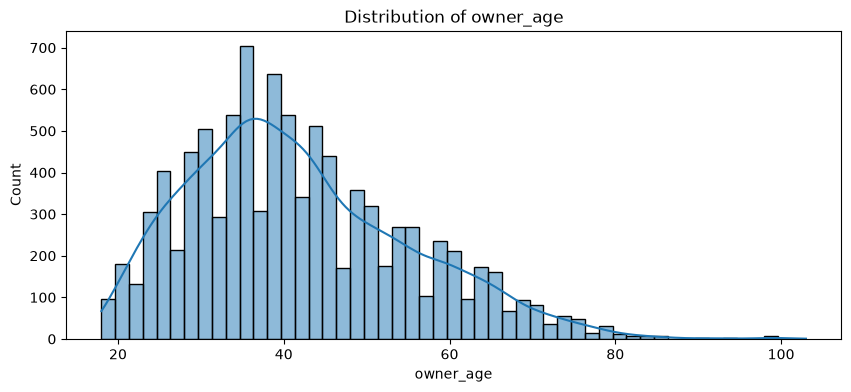

coll mean 41.70534414639218
coll median 40.0
coll max 103.0
coll min 18.0


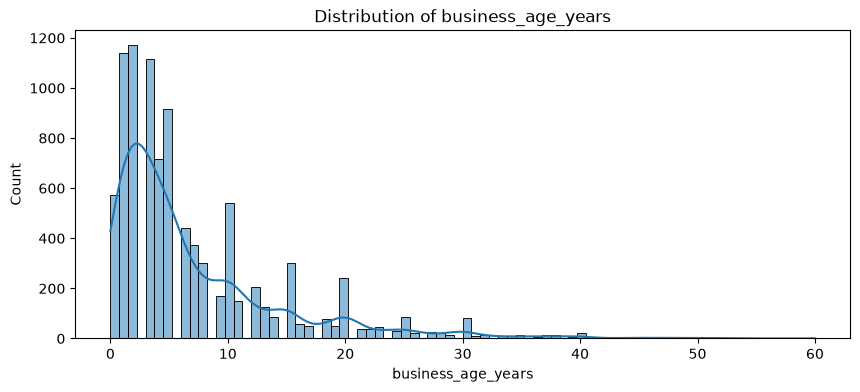

coll mean 7.030535981208627
coll median 4.0
coll max 60.0
coll min 0.0


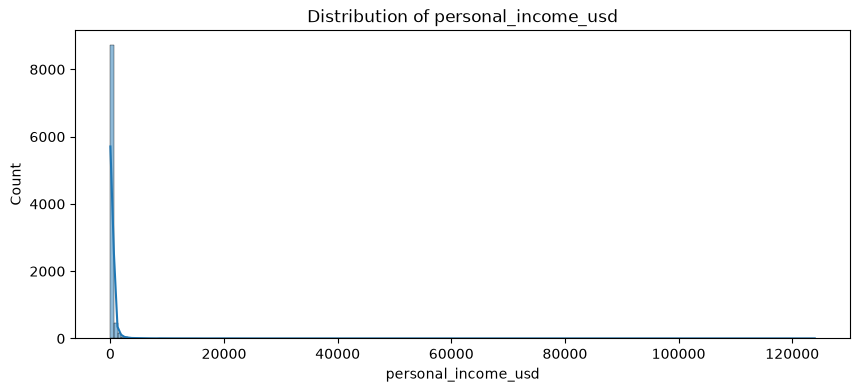

coll mean 328.64464444105585
coll median 69.6
coll max 124000.0
coll min 0.0


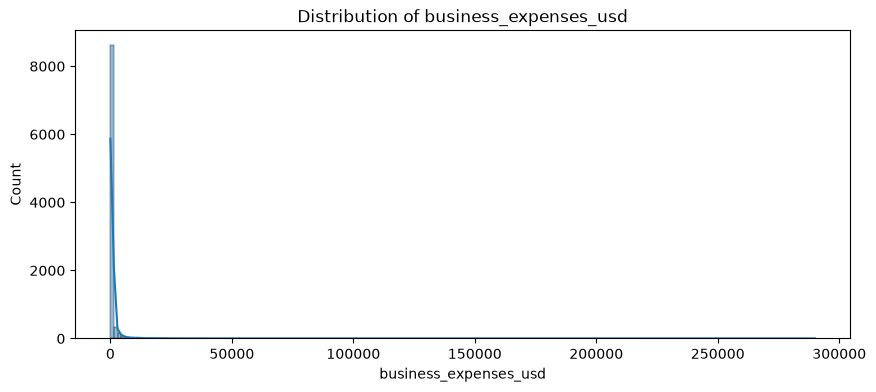

coll mean 778.6896194056875
coll median 66.6
coll max 290000.0
coll min 0.0


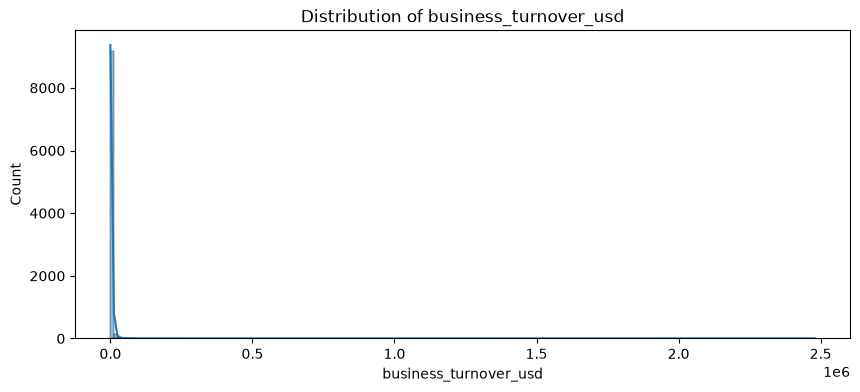

coll mean 2321.1733247117636
coll median 174.0
coll max 2480001.2399999998
coll min 0.0


In [36]:
# checking distribution in numerical columns
for coll in numm_cols:
    plt.figure(figsize=(10,4))
    sns.histplot(data=fhp_df,x=coll,kde=True)
    plt.xlabel(coll)
    plt.title(f'Distribution of {coll}')
    plt.show()
    print(f'coll mean {fhp_df[coll].mean()}')
    print(f'coll median {fhp_df[coll].median()}')
    print(f'coll max {fhp_df[coll].max()}')
    print(f'coll min {fhp_df[coll].min()}')


__Inspecting Outliers in the numerical columns__

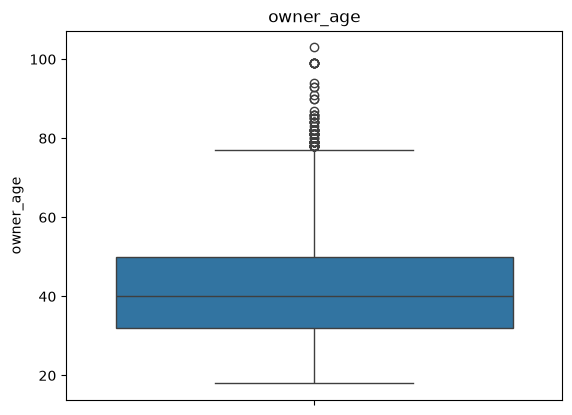

owner_age
 mean 41.70534414639218
 median 40.0
 max 103.0
 min 18.0


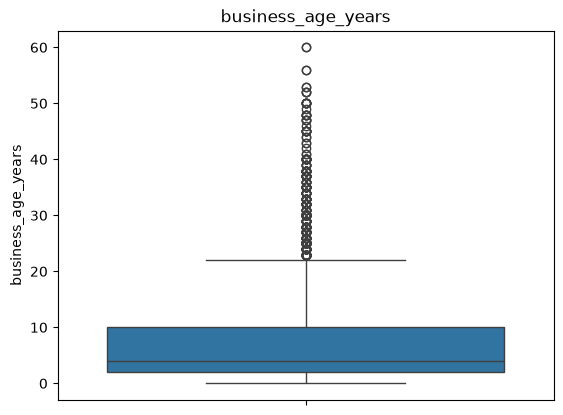

business_age_years
 mean 7.030535981208627
 median 4.0
 max 60.0
 min 0.0


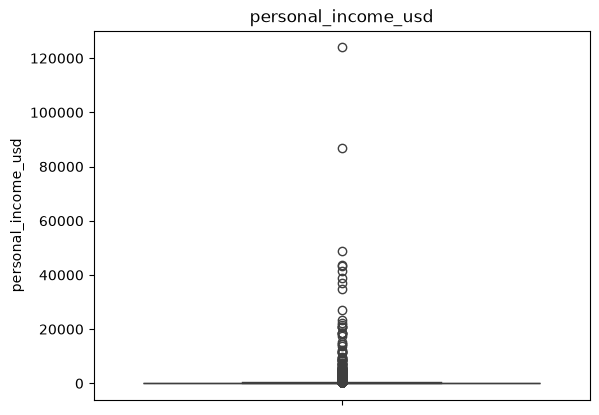

personal_income_usd
 mean 328.64464444105585
 median 69.6
 max 124000.0
 min 0.0


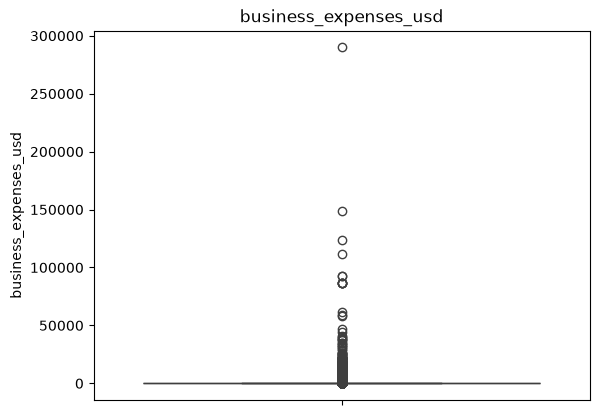

business_expenses_usd
 mean 778.6896194056875
 median 66.6
 max 290000.0
 min 0.0


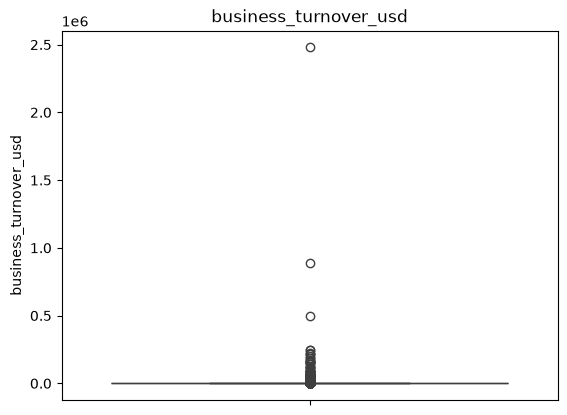

business_turnover_usd
 mean 2321.1733247117636
 median 174.0
 max 2480001.2399999998
 min 0.0


In [37]:
# Checking for outliers
for coll in numm_cols:
    plt.Figure(figsize=(5,6))
    sns.boxplot(data = fhp_df[coll])
    plt.title(coll)
    plt.show()
    print(coll) 
    print(f' mean {fhp_df[coll].mean()}')
    print(f' median {fhp_df[coll].median()}')
    print(f' max {fhp_df[coll].max()}')
    print(f' min {fhp_df[coll].min()}')


In [38]:
# Dropping business expenses column - There is uncertainty on whether the amounts are annual or monthly
fhp_df = fhp_df.drop(columns = ["business_expenses_usd"])

__Inspecting entries with personal income being greater than turnover__

In [39]:
total_count = (fhp_df["personal_income_usd"] > fhp_df["business_turnover_usd"]).sum()
print(total_count)

2254


In [40]:
# Filtering out personal income greater that business turnover (Monthly income is unlikely to be higher than annual business turnover in this case)
fhp_df = fhp_df[fhp_df["personal_income_usd"]< fhp_df["business_turnover_usd"]].copy()

__FIlling missing values in numerical columns with respective median__

In [41]:
numm_cols.remove("business_expenses_usd")
fhp_df[numm_cols] = fhp_df[numm_cols].fillna(fhp_df[numm_cols].median())

In [42]:
pd.set_option('display.max_columns',None)

In [43]:
fhp_df.head()

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,business_age_years,motor_vehicle_insurance,has_mobile_money,current_problem_cash_flow,has_cellphone,owner_sex,offers_credit_to_customers,attitude_satisfied_with_achievement,has_credit_card,keeps_financial_records,perception_insurance_companies_dont_insure_businesses_like_yours,perception_insurance_important,has_insurance,covid_essential_service,attitude_more_successful_next_year,problem_sourcing_money,marketing_word_of_mouth,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target,personal_income_usd,business_turnover_usd
0,id_3cfl0u,eswatini,63.0,yes,no,no,no,yes,14.0,never had,have now,yes,yes,male,"yes, sometimes",no,never had,"yes, always",yes,yes,no,yes,yes,yes,yes,never had,never had,never had,unknown,never had,used to have but don’t have now,unknown,never had,never had,low,186.00,434.00
4,id_13reys,zimbabwe,43.0,yes,no,no,yes,yes,3.0,never had,have now,unknown,no,female,"yes, sometimes",yes,never had,no,yes,yes,no,no,yes,unknown,unknown,unknown,unknown,unknown,no,never had,never had,yes,unknown,unknown,low,1.85,66.60
7,id_kb700u,eswatini,44.0,yes,yes,no,yes,yes,1.0,never had,have now,yes,yes,male,no,no,never had,"yes, always",no,yes,no,don't know,yes,yes,yes,never had,never had,never had,unknown,never had,never had,unknown,never had,never had,low,868.00,930.00
8,id_duqi8u,zimbabwe,34.0,yes,no,no,yes,yes,5.0,never had,have now,unknown,yes,female,no,yes,never had,"yes, sometimes",do not know / n‎/a,do not know / n‎/a,no,no,yes,unknown,unknown,unknown,unknown,unknown,no,never had,have now,yes,unknown,unknown,medium,5.55,124.32
9,id_27yh6u,eswatini,65.0,yes,no,yes,no,no,20.0,have now,have now,yes,yes,male,no,no,never had,"yes, always",no,yes,yes,no,yes,unknown,yes,never had,never had,have now,unknown,never had,have now,unknown,never had,never had,medium,310.00,1364.00


## __Exploratory Data Analysis (EDA)__

### 1. Descriptive Statistics

_Demographics_

In [44]:
# Gender distribution by country
gender_distribution = (pd.crosstab(fhp_df["country"],fhp_df["owner_sex"], normalize = "index")*100).round(2)
print(gender_distribution)

owner_sex  female   male
country                 
eswatini    59.77  40.23
lesotho    100.00   0.00
malawi      42.24  57.76
zimbabwe    64.68  35.32


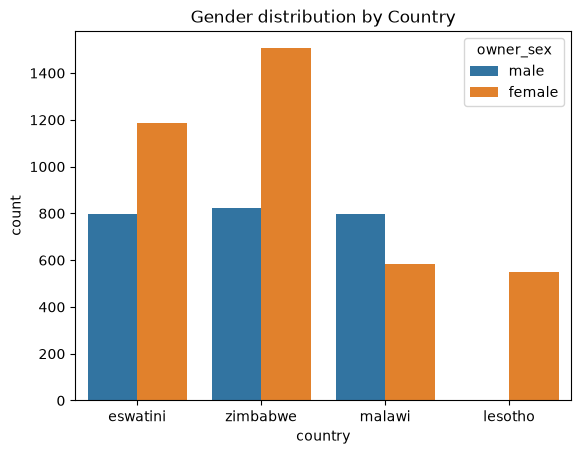

In [45]:
sns.countplot(data = fhp_df, x = "country", hue = "owner_sex")
plt.title("Gender distribution by Country")
plt.show()

In [46]:
bins = [18, 35, 50, 65, np.inf]
labels = ["Youth", "Middle_aged","Older Adults","Seniors"]

fhp_df["age_group"] = pd.cut(fhp_df["owner_age"], bins = bins , labels = labels, include_lowest = True)

age_distribution = (pd.crosstab(fhp_df["country"], fhp_df["age_group"], normalize = "index")*100).round(2)
age_distribution

age_group,Youth,Middle_aged,Older Adults,Seniors
country,,,,
eswatini,26.59,42.15,24.57,6.70
lesotho,32.12,35.57,24.86,7.44
malawi,48.55,40.20,9.72,1.52
zimbabwe,38.07,42.46,15.81,3.65


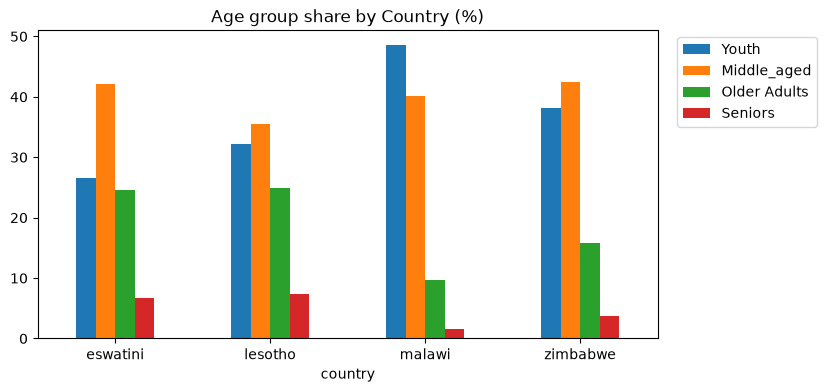

In [47]:
# Visual
age_distribution.plot(kind = "bar", figsize= (8,4))
plt.title("Age group share by Country (%)")
plt.legend(bbox_to_anchor=(1.02, 1),loc="upper left") # Moves legend outside the plot area
plt.xticks(rotation = 360)
plt.show()

_Compliance_

In [48]:
# 
(fhp_df["compliance_income_tax"].value_counts(normalize="percent")*100).reset_index()

,compliance_income_tax,proportion
0,no,81.896828
1,yes,14.322333
2,don’t know,3.684716
3,refused,0.096123


In [49]:
compliance_by_country = pd.crosstab(fhp_df["country"], fhp_df["compliance_income_tax"], normalize = "index")*100
compliance_by_country = compliance_by_country.drop(columns = ["don’t know", "refused"])
compliance_by_country

compliance_income_tax,no,yes
country,,
eswatini,73.413897,26.485398
lesotho,91.651543,6.170599
malawi,80.986938,15.892598
zimbabwe,87.365707,4.941985


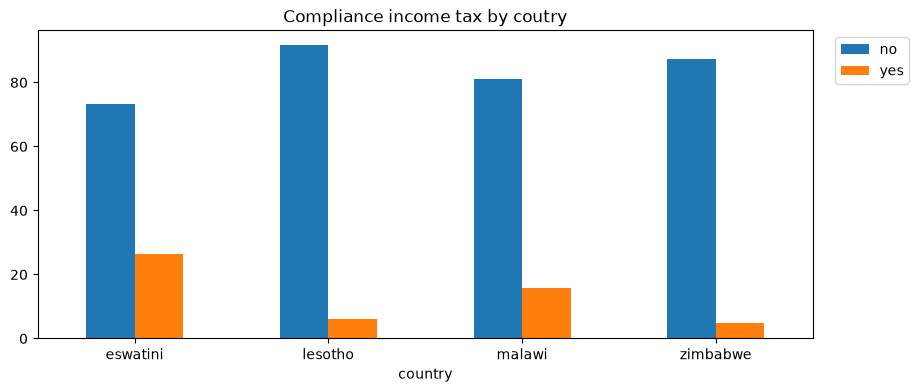

In [50]:
compliance_by_country.plot(kind = "bar", figsize=(10,4))
plt.title("Compliance income tax by coutry")
plt.xticks(rotation = 360)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

_Businesses with current problems in cashflow and offering credit to customers_

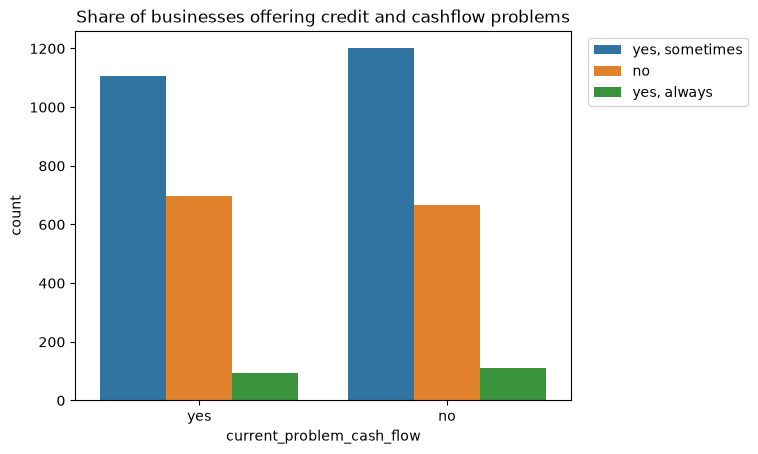

In [51]:
actual_plot = fhp_df[(fhp_df["current_problem_cash_flow"]!="unknown")]
sns.countplot(data = actual_plot, x = "current_problem_cash_flow", hue= "offers_credit_to_customers")
plt.title("Share of businesses offering credit and cashflow problems")
plt.legend(bbox_to_anchor = (1.02, 1), loc = "upper left")
plt.show()

### 2. Analytic Approach (Inferrential Statistics)

_Correlation Analysis_

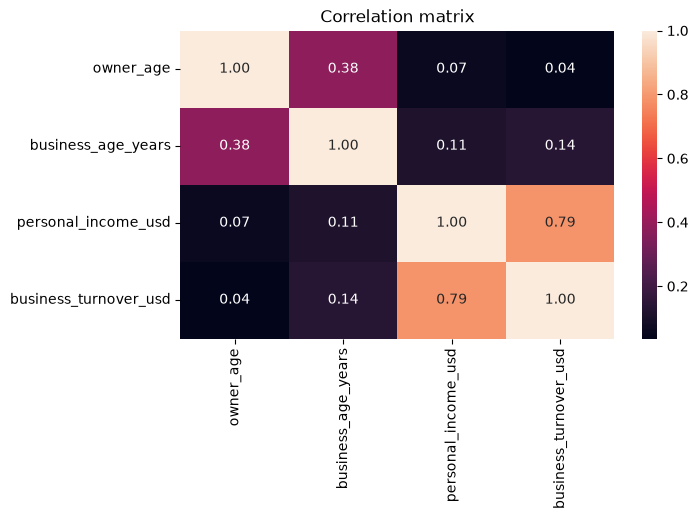

In [52]:
correlation = fhp_df[numm_cols].corr(method = "spearman")

plt.figure(figsize=(7,4))
sns.heatmap(correlation, annot= True, fmt = ".2f")
plt.title("Correlation matrix")
plt.show()

__Coefficient of determination__

In [53]:
# Personal income and business turnover
r = fhp_df["business_turnover_usd"].corr(fhp_df["personal_income_usd"], method = "spearman")
# You have to include the non parametric method if the data is skewed
r_squared = r ** 2
print(f"Correlation Coefficient (r): {r}")
print(f"Coefficient of Determination (r2): {r_squared}")

Correlation Coefficient (r): 0.7883315878773242
Coefficient of Determination (r2): 0.6214666924451833


In [54]:
# Owner age and business age
r = fhp_df["business_age_years"].corr(fhp_df["owner_age"], method = "spearman")
# You have to include the non parametric method if the data is skewed
r_squared = r ** 2
print(f"Correlation Coefficient (r): {r}")
print(f"Coefficient of Determination (r2): {r_squared}")

Correlation Coefficient (r): 0.37999983538308474
Coefficient of Determination (r2): 0.1443998748911715


_Hypothesis Testing_

In [55]:
categorical_columns = fhp_df.select_dtypes(include = ["str", "object"]).columns.tolist()
categorical_columns.remove("Target")
categorical_columns.remove("ID")



In [56]:
# Checking the relationship between categorical columns with the target
for col in categorical_columns:
    H0 = f"There is no  relationship between Target and {col}"
    H1 = f"There is a relationship between Target and {col}"

    alpha = 0.01
    contingency_table = pd.crosstab(fhp_df[col],fhp_df['Target'])
    chi2,p_value,dof,expected = chi2_contingency(contingency_table)
    print(p_value) 
    if p_value < alpha:
        print(f'Reject the the null hypothesis which is: ({H0})')
    else:
        print(f'Fail to reject the null hypothesis which is: ({H0})')
       

5.9087671920745964e-102
Reject the the null hypothesis which is: (There is no  relationship between Target and country)
5.576922746234595e-10
Reject the the null hypothesis which is: (There is no  relationship between Target and attitude_stable_business_environment)
2.1081815308647316e-12
Reject the the null hypothesis which is: (There is no  relationship between Target and attitude_worried_shutdown)
2.283845172084136e-87
Reject the the null hypothesis which is: (There is no  relationship between Target and compliance_income_tax)
9.826554936512267e-41
Reject the the null hypothesis which is: (There is no  relationship between Target and perception_insurance_doesnt_cover_losses)
4.102133356737551e-31
Reject the the null hypothesis which is: (There is no  relationship between Target and perception_cannot_afford_insurance)
1.2609377318767414e-115
Reject the the null hypothesis which is: (There is no  relationship between Target and motor_vehicle_insurance)
2.1219865585415523e-08
Reject th

**Checking for relationship between numerical columns and the target**

In [57]:
numm_cols

['owner_age',
 'business_age_years',
 'personal_income_usd',
 'business_turnover_usd']

In [58]:

alpha = 0.05

for col in numm_cols:
    groups = [group[col] for name, group in fhp_df.groupby('Target') ]

    # Kruskal-Wallis test
    statistic, p_value = kruskal(*groups)

    H0 = f"There is no difference in {col} across Target groups"
    H1 = f"There is a difference in {col} across Target groups"

    print(f"{col}:")
    print(f"  H-statistic = {statistic:.3f}")
    print(f"  p-value = {p_value:.5f}")

    if p_value < alpha:
       print(f"Reject H0 which is : ({H0})")
    else:
        print(f"Fail to reject wich is: ({H0})")


owner_age:
  H-statistic = 111.157
  p-value = 0.00000
Reject H0 which is : (There is no difference in owner_age across Target groups)
business_age_years:
  H-statistic = 24.144
  p-value = 0.00001
Reject H0 which is : (There is no difference in business_age_years across Target groups)
personal_income_usd:
  H-statistic = 283.803
  p-value = 0.00000
Reject H0 which is : (There is no difference in personal_income_usd across Target groups)
business_turnover_usd:
  H-statistic = 241.062
  p-value = 0.00000
Reject H0 which is : (There is no difference in business_turnover_usd across Target groups)


In [59]:
fhp_df.head()

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,business_age_years,motor_vehicle_insurance,has_mobile_money,current_problem_cash_flow,has_cellphone,owner_sex,offers_credit_to_customers,attitude_satisfied_with_achievement,has_credit_card,keeps_financial_records,perception_insurance_companies_dont_insure_businesses_like_yours,perception_insurance_important,has_insurance,covid_essential_service,attitude_more_successful_next_year,problem_sourcing_money,marketing_word_of_mouth,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target,personal_income_usd,business_turnover_usd,age_group
0,id_3cfl0u,eswatini,63.0,yes,no,no,no,yes,14.0,never had,have now,yes,yes,male,"yes, sometimes",no,never had,"yes, always",yes,yes,no,yes,yes,yes,yes,never had,never had,never had,unknown,never had,used to have but don’t have now,unknown,never had,never had,low,186.00,434.00,Older Adults
4,id_13reys,zimbabwe,43.0,yes,no,no,yes,yes,3.0,never had,have now,unknown,no,female,"yes, sometimes",yes,never had,no,yes,yes,no,no,yes,unknown,unknown,unknown,unknown,unknown,no,never had,never had,yes,unknown,unknown,low,1.85,66.60,Middle_aged
7,id_kb700u,eswatini,44.0,yes,yes,no,yes,yes,1.0,never had,have now,yes,yes,male,no,no,never had,"yes, always",no,yes,no,don't know,yes,yes,yes,never had,never had,never had,unknown,never had,never had,unknown,never had,never had,low,868.00,930.00,Middle_aged
8,id_duqi8u,zimbabwe,34.0,yes,no,no,yes,yes,5.0,never had,have now,unknown,yes,female,no,yes,never had,"yes, sometimes",do not know / n‎/a,do not know / n‎/a,no,no,yes,unknown,unknown,unknown,unknown,unknown,no,never had,have now,yes,unknown,unknown,medium,5.55,124.32,Youth
9,id_27yh6u,eswatini,65.0,yes,no,yes,no,no,20.0,have now,have now,yes,yes,male,no,no,never had,"yes, always",no,yes,yes,no,yes,unknown,yes,never had,never had,have now,unknown,never had,have now,unknown,never had,never had,medium,310.00,1364.00,Older Adults


In [60]:
fhp_df = fhp_df.drop(columns=["age_group", "ID"], errors="ignore")

# Machine Learning

**variance inflation Factor**

In [61]:
numm_cols    
# Select only the independent predictor variables
X_nums = fhp_df[numm_cols]
# Add a constant column for the intercept.   
X_nums_with_constant = X_nums.copy()
X_nums_with_constant['constant'] = 1

# Calculate the VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_nums.columns
vif_data["VIF"] = [variance_inflation_factor(X_nums_with_constant.values, i) 
                    for i in range(len(X_nums.columns))]

print(vif_data)

                 feature       VIF
0              owner_age  1.224346
1     business_age_years  1.232560
2    personal_income_usd  1.034369
3  business_turnover_usd  1.031380


${VIF}_{i}=\frac{1}{1-R_{i}^{2}}$      

Interpretation:      
VIF = 1: No multicollinearity, the variables are completely independent.     
VIF 1 to 5: Moderate correlation; Usually not an issue for regression models.     
VIF 5 to 10: High Correlation amongst independent variables.    
VIF > 10: Serious multicollinearity. 

In [62]:
### splitting feature columns from the target
X = fhp_df.drop(columns=['Target'])
y = fhp_df['Target']

In [63]:
### Splitting financial health prediction dataset into test and ttrain dataset
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)

## Encoding the categorical columns

In [64]:
# Label encoding the target column
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [65]:
#   Encoding the feature categorical columns
X_train = pd.get_dummies(X_train,columns=categorical_columns,dtype=int,drop_first=True)
X_test = pd.get_dummies(X_test,columns=categorical_columns,dtype=int,drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

## Scaling numerical columns

In [66]:
numm_cols

['owner_age',
 'business_age_years',
 'personal_income_usd',
 'business_turnover_usd']

In [67]:
scaler = RobustScaler()
X_train[numm_cols] = scaler.fit_transform(X_train[numm_cols])
X_test[numm_cols] = scaler.transform(X_test[numm_cols])

## Training the model and making predictions

### Logistic Regression

In [68]:
# Instantiate the model
logistic_model = LogisticRegression(max_iter=2000)
# Fitting the model
logistic_model.fit(X_train, y_train_encoded)
#Predictions
y_prediction = logistic_model.predict(X_test)

print("classification_report \n", classification_report(y_test_encoded, y_prediction, target_names=le.classes_))

classification_report 
               precision    recall  f1-score   support

        high       0.62      0.28      0.38        72
         low       0.87      0.99      0.92       773
      medium       0.84      0.70      0.76       404

    accuracy                           0.85      1249
   macro avg       0.78      0.65      0.69      1249
weighted avg       0.84      0.85      0.84      1249



### Decision Trees

In [69]:
# Instantiate the model
decision_model = DecisionTreeClassifier(max_depth=10)
# Train the model
decision_model.fit(X_train, y_train_encoded)
# Make prediction
decision_pred = decision_model.predict(X_test)
# Evaluate the model

print('Decision_tree_classification_report \n', classification_report(y_test_encoded, decision_pred, target_names=le.classes_))

Decision_tree_classification_report 
               precision    recall  f1-score   support

        high       0.61      0.38      0.47        72
         low       0.86      0.99      0.92       773
      medium       0.85      0.67      0.75       404

    accuracy                           0.85      1249
   macro avg       0.77      0.68      0.71      1249
weighted avg       0.84      0.85      0.84      1249



### KNN Neighbours

_Euclidean_

In [70]:
# Instantiate the model
knn_model = KNeighborsClassifier(n_neighbors=7, metric='euclidean')
# Fit the model
knn_model.fit(X_train, y_train_encoded)
# Make predictions
knn_pred = knn_model.predict(X_test)
# Evaluate the model

print('KNN_classification_report \n', classification_report(y_test_encoded, knn_pred, target_names=le.classes_))

KNN_classification_report 
               precision    recall  f1-score   support

        high       0.66      0.26      0.38        72
         low       0.77      0.97      0.86       773
      medium       0.77      0.48      0.59       404

    accuracy                           0.77      1249
   macro avg       0.73      0.57      0.61      1249
weighted avg       0.77      0.77      0.75      1249



_Manhattan_

In [71]:
# Instantiate the model
knn_model = KNeighborsClassifier(n_neighbors=7, metric='manhattan')
# Fit the model
knn_model.fit(X_train, y_train_encoded)
# Make predictions
knn_pred = knn_model.predict(X_test)
# Evaluate the model

print('KNN_classification_report \n', classification_report(y_test_encoded, knn_pred, target_names=le.classes_))

KNN_classification_report 
               precision    recall  f1-score   support

        high       0.64      0.22      0.33        72
         low       0.79      0.97      0.87       773
      medium       0.76      0.52      0.62       404

    accuracy                           0.78      1249
   macro avg       0.73      0.57      0.61      1249
weighted avg       0.77      0.78      0.76      1249



_Minowski_

In [72]:
# Instantiate the model
knn_model = KNeighborsClassifier(n_neighbors=7, metric='minkowski')
# Fit the model
knn_model.fit(X_train, y_train_encoded)
# Make predictions
knn_pred = knn_model.predict(X_test)
# Evaluate the model

print('KNN_classification_report \n', classification_report(y_test_encoded, knn_pred, target_names=le.classes_))

KNN_classification_report 
               precision    recall  f1-score   support

        high       0.66      0.26      0.38        72
         low       0.77      0.97      0.86       773
      medium       0.77      0.48      0.59       404

    accuracy                           0.77      1249
   macro avg       0.73      0.57      0.61      1249
weighted avg       0.77      0.77      0.75      1249



## Ensemble Methods

### Bagging

_Random Forest_

In [73]:
# Instantiate the model
random_forest = RandomForestClassifier(n_estimators=1000, max_depth=4)
# Train the model
random_forest.fit(X_train, y_train_encoded)
# Make prediction
rf_pred = random_forest.predict(X_test)
#Evaluate the model

print('Random_Forest_classification_report \n', classification_report(y_test_encoded, rf_pred, target_names=le.classes_))

Random_Forest_classification_report 
               precision    recall  f1-score   support

        high       1.00      0.11      0.20        72
         low       0.80      1.00      0.89       773
      medium       0.81      0.56      0.66       404

    accuracy                           0.81      1249
   macro avg       0.87      0.56      0.58      1249
weighted avg       0.82      0.81      0.78      1249



### Boosting

- __Gradient Boosting__

In [74]:
# Instatiate the model
gb_model = GradientBoostingClassifier(n_estimators=1000, max_depth=4)
# Train the model
gb_model.fit(X_train, y_train_encoded)
# Make prediction
gb_pred = gb_model.predict(X_test)
# Evaluate the model

print('Gradient Boosting Classification report: \n', classification_report(y_test_encoded, gb_pred, target_names=le.classes_))

Gradient Boosting Classification report: 
               precision    recall  f1-score   support

        high       0.62      0.28      0.38        72
         low       0.87      0.97      0.92       773
      medium       0.81      0.71      0.76       404

    accuracy                           0.85      1249
   macro avg       0.77      0.65      0.69      1249
weighted avg       0.84      0.85      0.84      1249



- __XG Boost__

In [75]:
# Instantiate the model
xgb_model = XGBClassifier(n_estimators=200, max_depth=4)
# Train the model
xgb_model.fit(X_train, y_train_encoded)
# Make prediction
xgb_pred = xgb_model.predict(X_test)
# Evaluate the model

print('XGBoost classification report: \n', classification_report(y_test_encoded, xgb_pred, target_names=le.classes_))

XGBoost classification report: 
               precision    recall  f1-score   support

        high       0.85      0.24      0.37        72
         low       0.87      0.98      0.92       773
      medium       0.82      0.73      0.77       404

    accuracy                           0.86      1249
   macro avg       0.85      0.65      0.69      1249
weighted avg       0.85      0.86      0.84      1249



### Support Vector Machine (SVM)

In [76]:
#Instantiate the model
svm_model =SVC(kernel='rbf', gamma='auto')
# Train/fit the model
svm_model.fit(X_train,y_train_encoded)
# Make prediction
svm_pred = svm_model.predict(X_test)
# Evaluate the model 

print('SVM Classification Report: \n', classification_report(y_test_encoded, svm_pred, target_names=le.classes_)) 

SVM Classification Report: 
               precision    recall  f1-score   support

        high       0.75      0.21      0.33        72
         low       0.81      0.99      0.89       773
      medium       0.82      0.58      0.68       404

    accuracy                           0.81      1249
   macro avg       0.79      0.59      0.63      1249
weighted avg       0.81      0.81      0.79      1249

